# Experiment Visualization from Training Logs

**This notebook is used for visualizing the experiments of LayerGCN, we have colllected the training logs (in .txt format) in all of the ipynbs inside the experiment folder with the same format structure and plotting necessary metrics into graph for better visualization**

In [2]:
import re
import matplotlib.pyplot as plt
import numpy as np
import os


**We write a plotting function to visualize the 2 important metrics: Recall and NDCG as well as visualizing the system metrics performance base on the Training Log Pattern Extracted from the logs file**

**Example Training Log Sample**

```
epoch 0 training [time: 208.42s, train loss: 550316.0862]
RAM:1896.8MB | CPU:2.5% | VRAM:329.6MB/22563.1MB
test result: 
recall@20: 0.0079    ndcg@20: 0.0059    map@20: 0.0018    precision@20: 0.0033
```

**We also utitlize the library to plot out metrics logs from tensorboard to get the recall and ndcg metrics**

In [3]:
def plot_metrics_from_multiline_log(log_path: str):
    epochs = []
    losses = []
    recalls = []
    ndcgs = []
    rams = []
    vrams = []

    title_prefix = os.path.splitext(os.path.basename(log_path))[0] + " run"

    epoch_re = re.compile(r"epoch\s+(\d+).*?train loss:\s*([\d.]+)", re.I)
    ram_re = re.compile(r"RAM:([\d.]+)MB.*?VRAM:([\d.]+)MB", re.I)
    metric_re = re.compile(r"recall@20:\s*([\d.]+).*?ndcg@20:\s*([\d.]+)", re.I)

    cur_epoch = None
    cur_loss = None
    cur_ram = None
    cur_vram = None

    with open(log_path, "r", encoding="utf-8") as f:
        for line in f:
            # Line 1: epoch + loss
            m1 = epoch_re.search(line)
            if m1:
                cur_epoch = int(m1.group(1))
                cur_loss = float(m1.group(2))
                continue

            # Line 2: RAM + VRAM
            m2 = ram_re.search(line)
            if m2:
                cur_ram = float(m2.group(1))
                cur_vram = float(m2.group(2))
                continue

            # Line 4: recall + ndcg
            m3 = metric_re.search(line)
            if m3 and cur_epoch is not None:
                recall = float(m3.group(1))
                ndcg = float(m3.group(2))

                # save one full epoch block
                epochs.append(cur_epoch)
                losses.append(cur_loss)
                recalls.append(recall)
                ndcgs.append(ndcg)
                rams.append(cur_ram)
                vrams.append(cur_vram)

                # reset
                cur_epoch = None

    # ===== Best metrics =====
    best_recall_idx = np.argmax(recalls)
    best_ndcg_idx = np.argmax(ndcgs)

    print(f"Best Recall : {recalls[best_recall_idx]:.6f} @ epoch {epochs[best_recall_idx]}")
    print(f"Best NDCG   : {ndcgs[best_ndcg_idx]:.6f} @ epoch {epochs[best_ndcg_idx]}")

    print(f"Average RAM : {np.mean(rams):.2f} MB")
    print(f"Average VRAM: {np.mean(vrams):.2f} MB")

    # ===== Plot =====
    fig, axs = plt.subplots(1, 4, figsize=(18, 4))

    # Loss
    axs[0].plot(epochs, losses, color = 'green')
    axs[0].set_title(f"{title_prefix} - Loss")
    axs[0].set_xlabel("Epoch")

    # Recall + NDCG
    axs[1].plot(epochs, recalls, label="Recall")
    axs[1].plot(epochs, ndcgs, label="NDCG")
    axs[1].scatter(epochs[best_recall_idx], recalls[best_recall_idx])
    axs[1].scatter(epochs[best_ndcg_idx], ndcgs[best_ndcg_idx])
    axs[1].legend()
    axs[1].set_title(f"{title_prefix} - Recall & NDCG")

    # RAM
    axs[2].plot(epochs, rams, color="blue")
    axs[2].set_title("RAM Usage")

    # VRAM
    axs[3].plot(epochs, vrams, color="blue")
    axs[3].set_title("VRAM Usage")

    plt.tight_layout()
    plt.show()

The function above parses a multi-line training log where each epoch’s information is spread across several lines, then:

Extracts Loss
Extracts Recall@20 and NDCG@20 (plotted together)
Extracts RAM and VRAM usage
Computes best Recall and best NDCG
Plots all metrics in a single figure with 4 subplots

This is required because the log format is not single-line per epoch.

**Yelp2018**

Best Recall : 0.052600 @ epoch 142
Best NDCG   : 0.042100 @ epoch 79
Average RAM : 1765.90 MB
Average VRAM: 182.28 MB


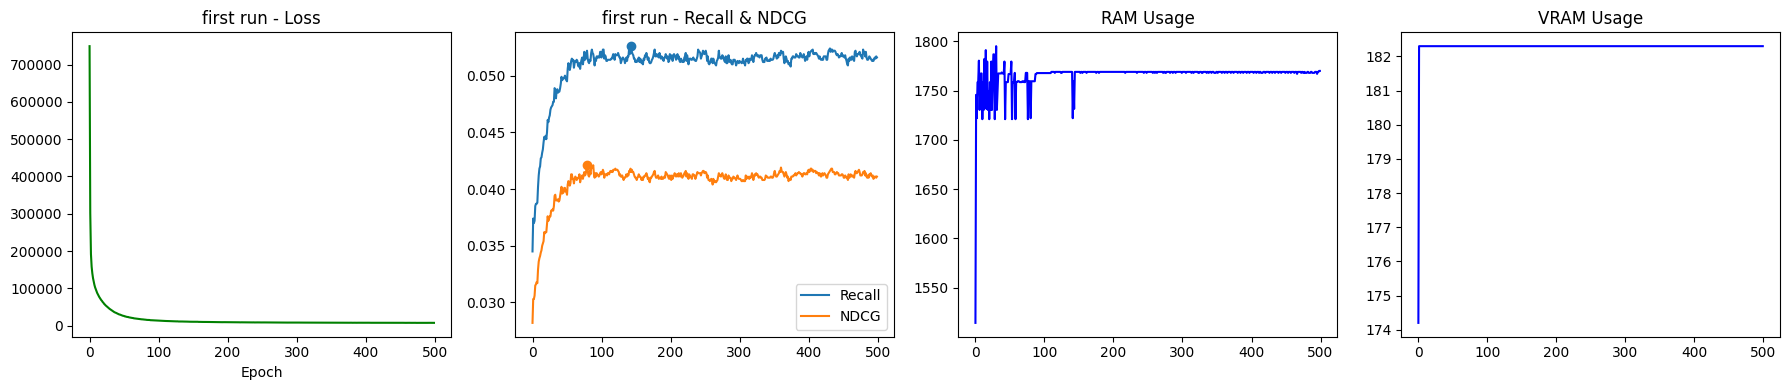

In [4]:
plot_metrics_from_multiline_log('yelp2018/first.txt')

Best Recall : 0.052600 @ epoch 142
Best NDCG   : 0.042100 @ epoch 79
Average RAM : 1756.64 MB
Average VRAM: 182.28 MB


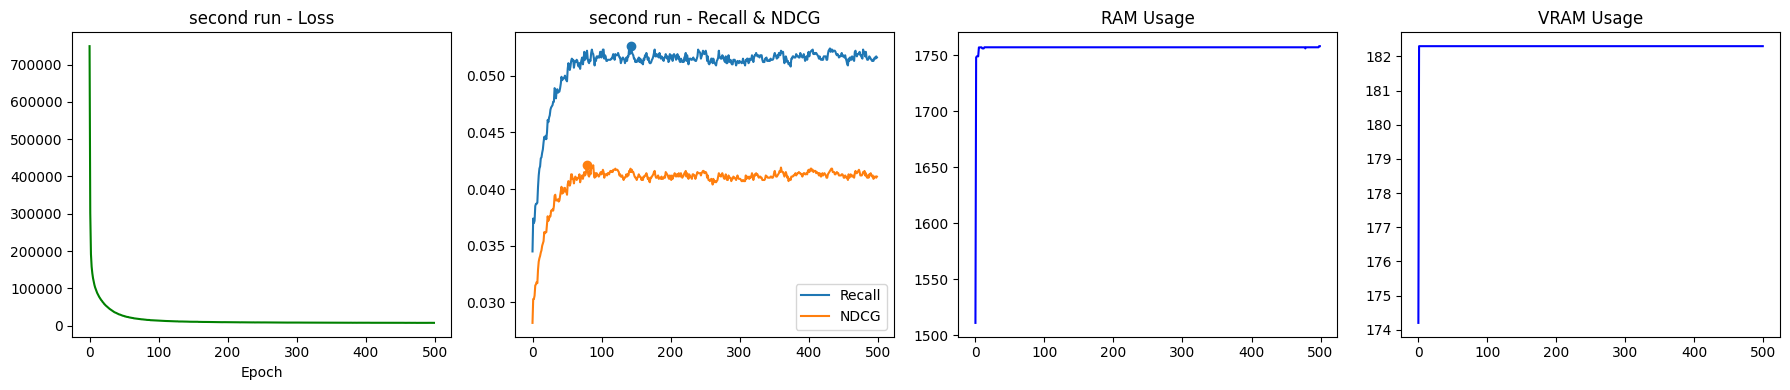

In [5]:
plot_metrics_from_multiline_log('yelp2018/second.txt')

Best Recall : 0.052600 @ epoch 142
Best NDCG   : 0.042100 @ epoch 79
Average RAM : 1746.07 MB
Average VRAM: 182.28 MB


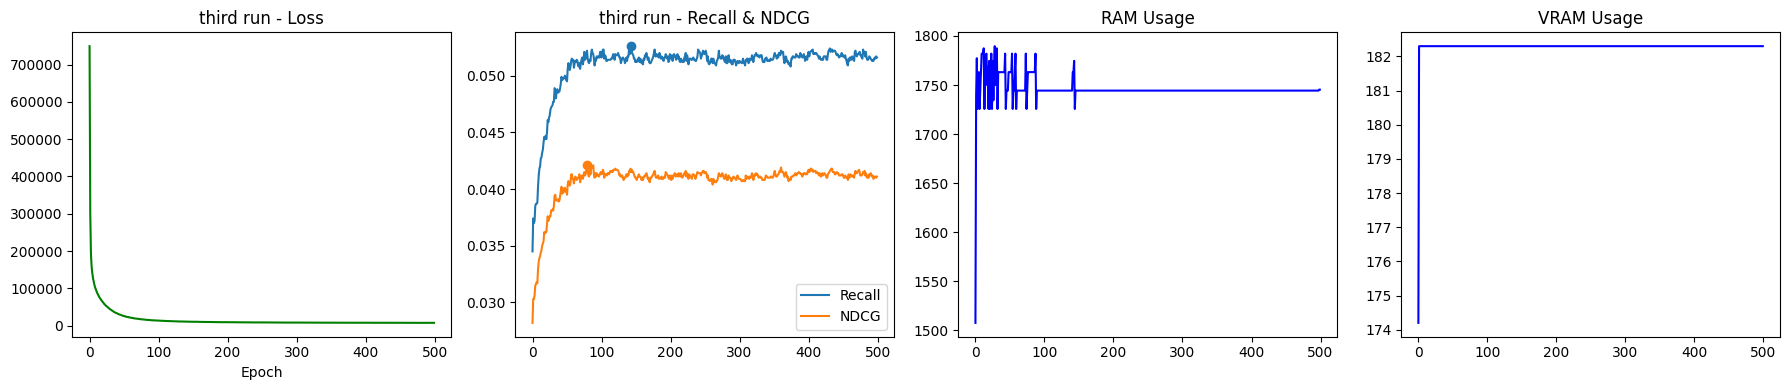

In [6]:
plot_metrics_from_multiline_log('yelp2018/third.txt')

**AmazonBook**

Best Recall : 0.013900 @ epoch 28
Best NDCG   : 0.010200 @ epoch 28
Average RAM : 2045.66 MB
Average VRAM: 338.07 MB


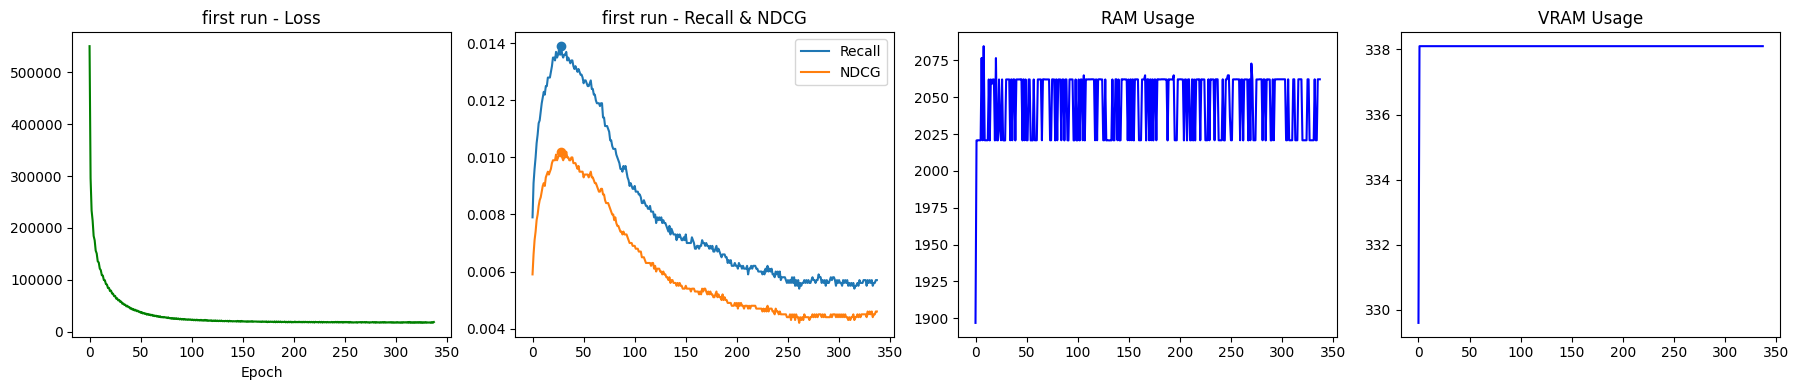

In [20]:
plot_metrics_from_multiline_log('amazonbook/first.txt')

Best Recall : 0.013900 @ epoch 28
Best NDCG   : 0.010200 @ epoch 28
Average RAM : 2035.90 MB
Average VRAM: 338.08 MB


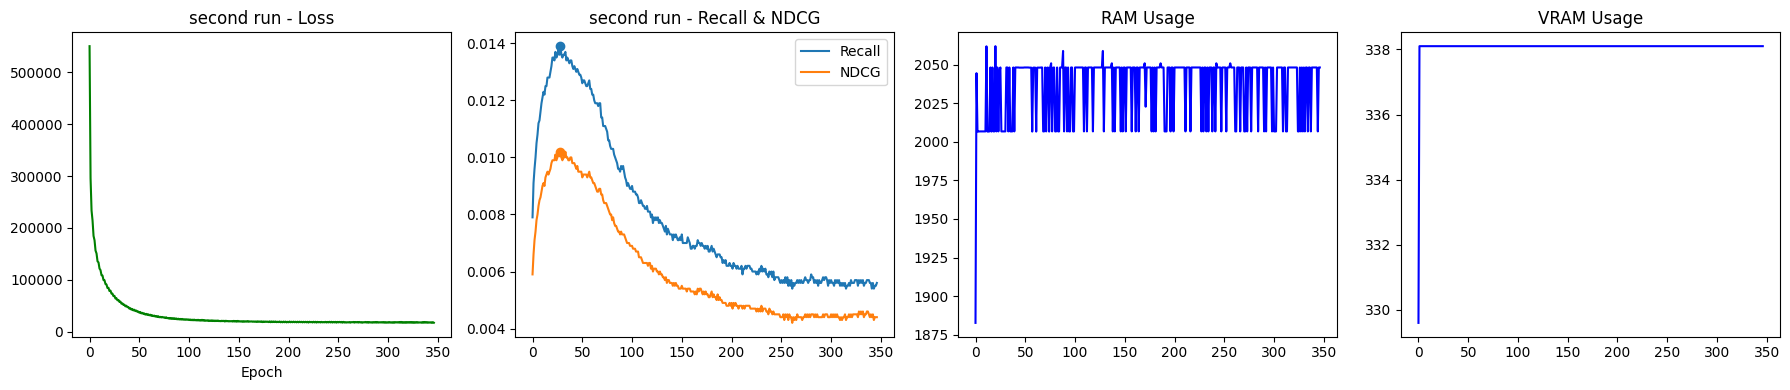

In [21]:
plot_metrics_from_multiline_log('amazonbook/second.txt')

Best Recall : 0.013900 @ epoch 28
Best NDCG   : 0.010200 @ epoch 28
Average RAM : 2024.56 MB
Average VRAM: 338.08 MB


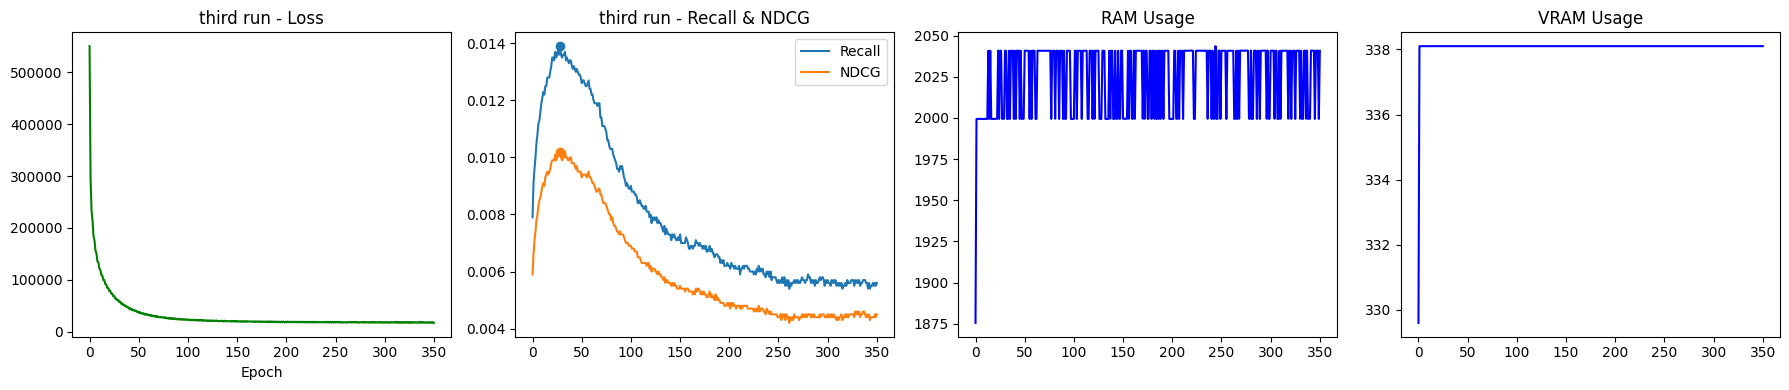

In [22]:
plot_metrics_from_multiline_log('amazonbook/third.txt')

**Gowalla**

Best Recall : 0.154100 @ epoch 497
Best NDCG   : 0.123100 @ epoch 497
Average RAM : 1688.88 MB
Average VRAM: 171.48 MB


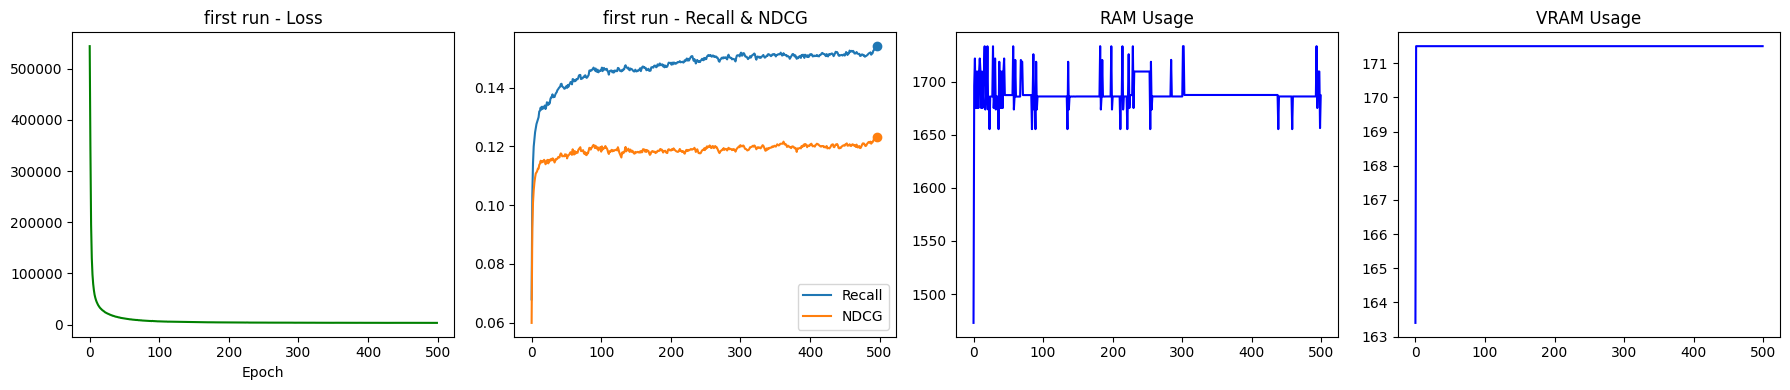

In [7]:
plot_metrics_from_multiline_log('gowalla/first.txt')

Best Recall : 0.154100 @ epoch 497
Best NDCG   : 0.123100 @ epoch 497
Average RAM : 1659.57 MB
Average VRAM: 171.48 MB


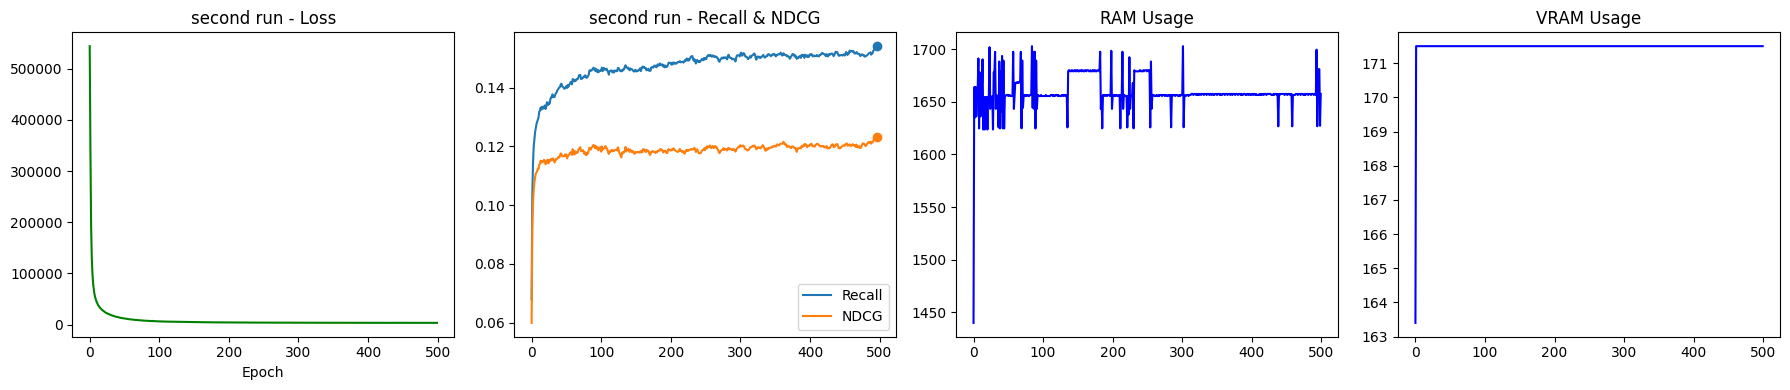

In [9]:
plot_metrics_from_multiline_log('gowalla/second.txt')

Best Recall : 0.154100 @ epoch 497
Best NDCG   : 0.123100 @ epoch 497
Average RAM : 1661.47 MB
Average VRAM: 171.48 MB


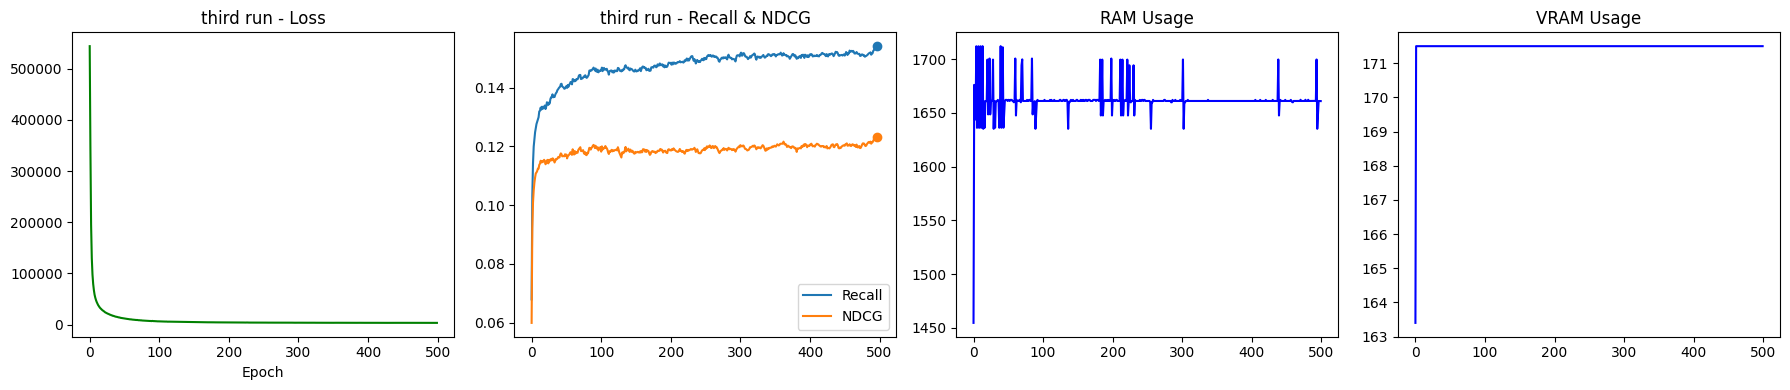

In [10]:
plot_metrics_from_multiline_log('gowalla/third.txt')

**MovieLen**

Best Recall : 0.239300 @ epoch 27
Best NDCG   : 0.228100 @ epoch 26
Average RAM : 1638.34 MB
Average VRAM: 52.68 MB


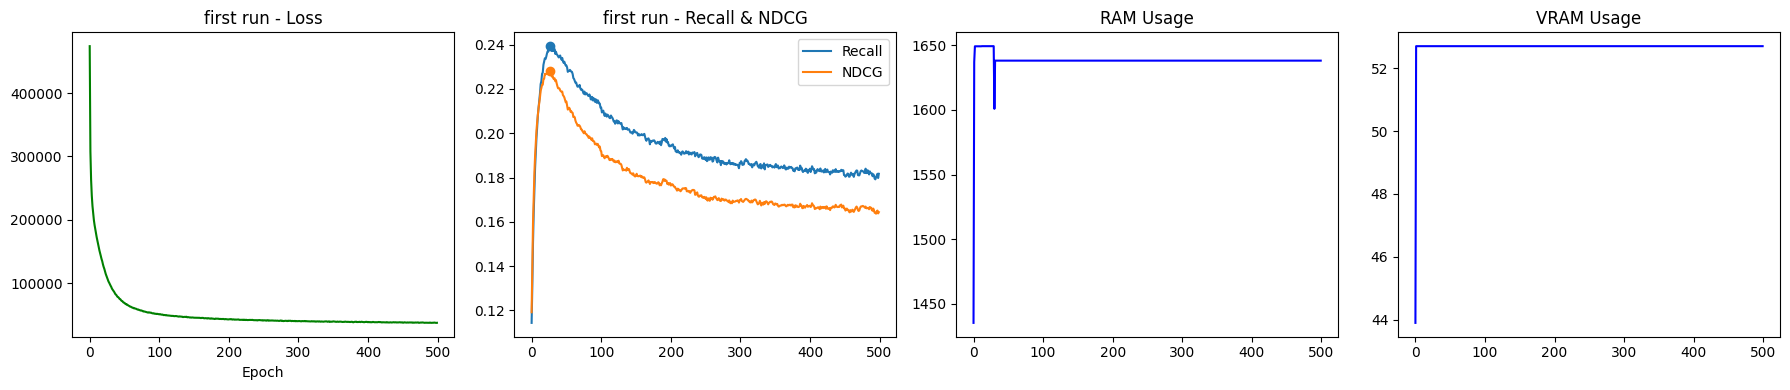

In [11]:
plot_metrics_from_multiline_log('movielen/first.txt')

Best Recall : 0.239300 @ epoch 27
Best NDCG   : 0.228100 @ epoch 26
Average RAM : 1633.50 MB
Average VRAM: 52.68 MB


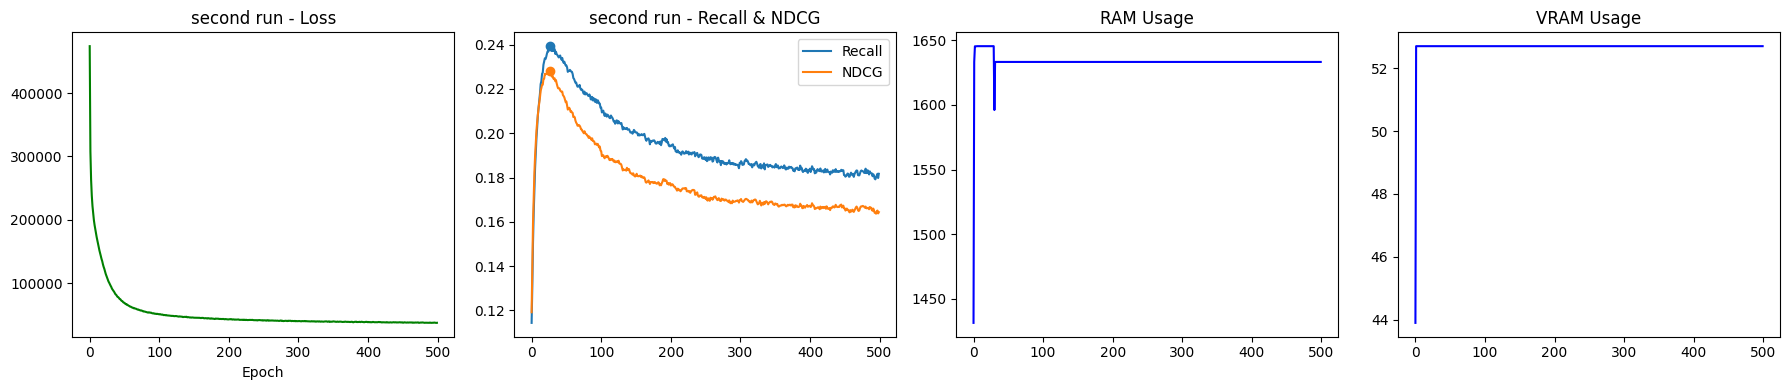

In [12]:
plot_metrics_from_multiline_log('movielen/second.txt')

Best Recall : 0.239300 @ epoch 27
Best NDCG   : 0.228100 @ epoch 26
Average RAM : 1650.65 MB
Average VRAM: 52.68 MB


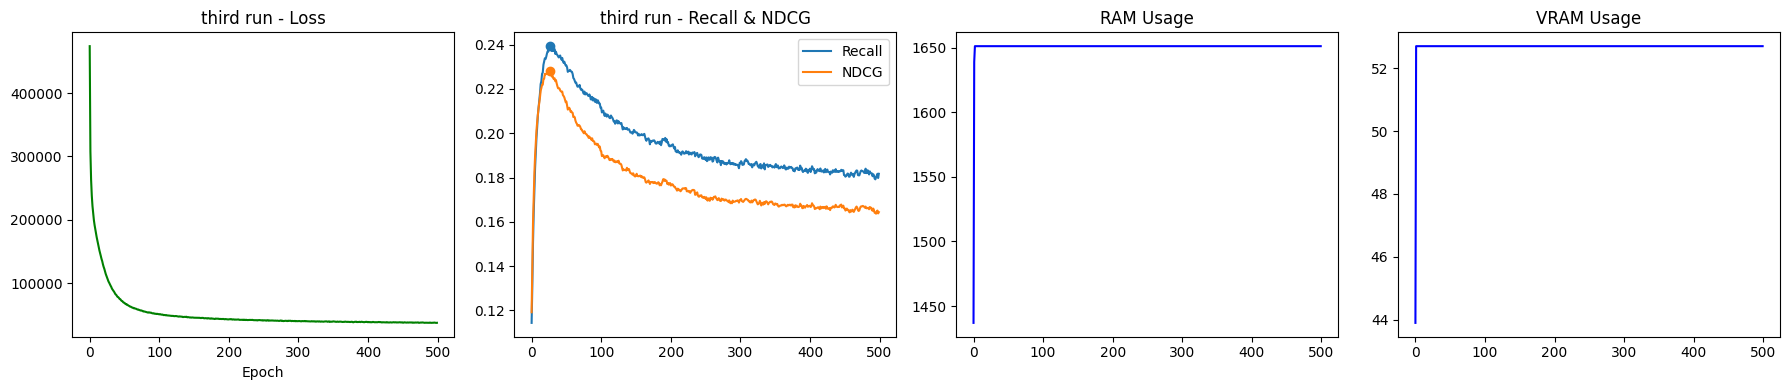

In [13]:
plot_metrics_from_multiline_log('movielen/third.txt')

**GitStar**

Best Recall : 0.041600 @ epoch 23
Best NDCG   : 0.017800 @ epoch 13
Average RAM : 1649.03 MB
Average VRAM: 76.58 MB


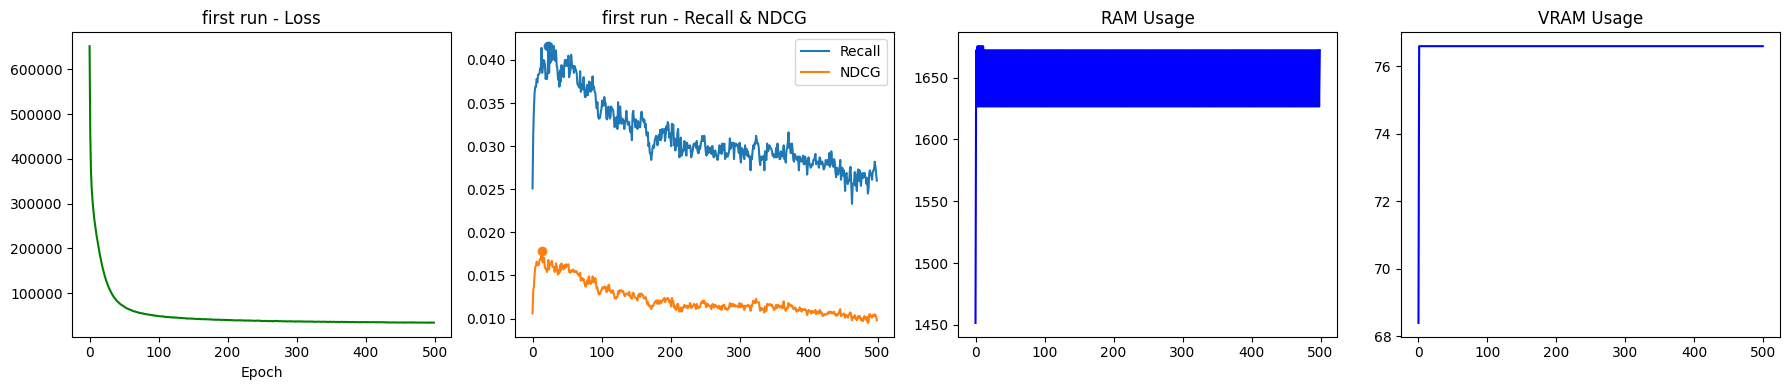

In [14]:
plot_metrics_from_multiline_log('gitstar/first.txt')

Best Recall : 0.041600 @ epoch 23
Best NDCG   : 0.017800 @ epoch 13
Average RAM : 1641.33 MB
Average VRAM: 76.58 MB


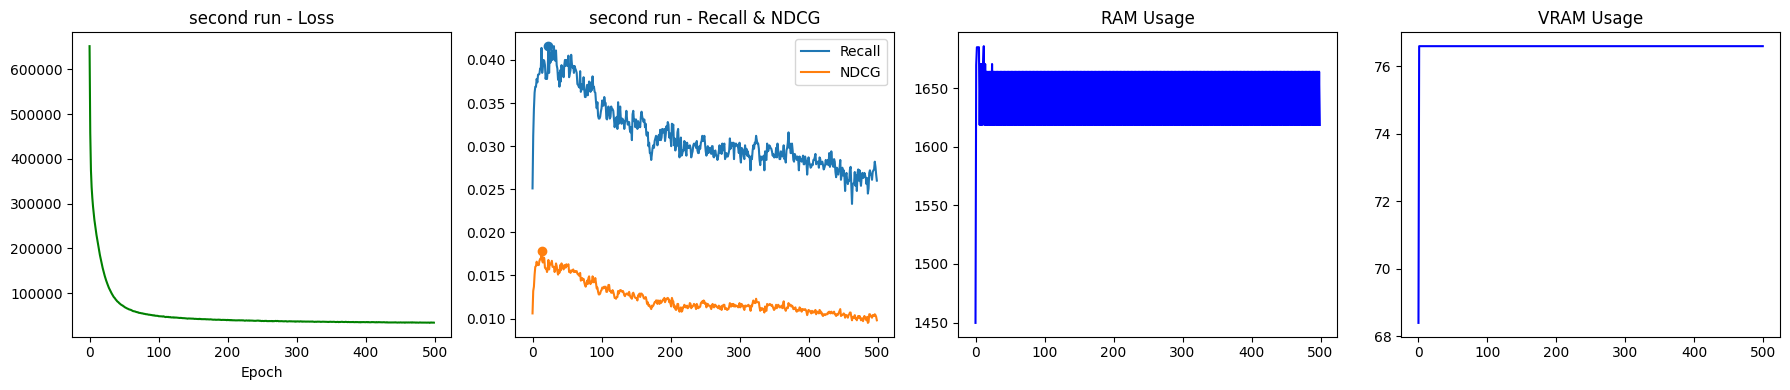

In [15]:
plot_metrics_from_multiline_log('gitstar/second.txt')

Best Recall : 0.041600 @ epoch 23
Best NDCG   : 0.017800 @ epoch 13
Average RAM : 1640.53 MB
Average VRAM: 76.58 MB


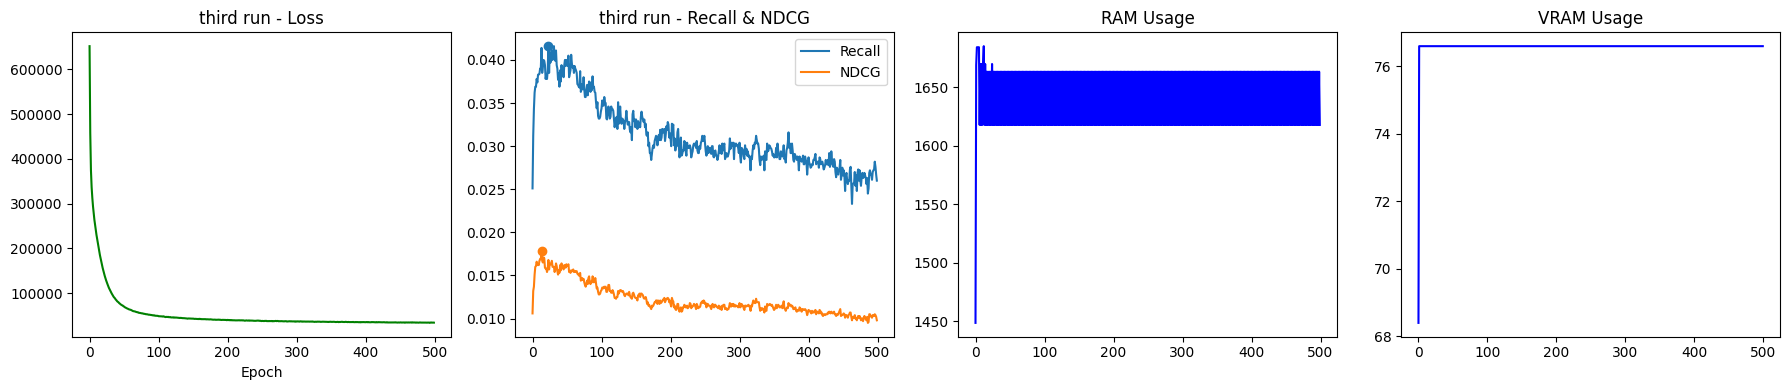

In [16]:
plot_metrics_from_multiline_log('gitstar/third.txt')